In [1]:
import sys
sys.path.append(r'/import/home2/yzengbj/my_project/code')

import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import os

import simulation as construct_st

In [2]:
DATA_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/additive' # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/experiments/additive" # Deconvolution results
os.makedirs(os.path.join(DATA_PATH), exist_ok = True)

In [25]:
factor_pattern = 'gradient_y'
factor_celltype = [0]

n_spots = 2000
n_genes = 2000
n_celltypes = 2
n_cells = 500
n_covariates = 1
n_loading_genes = 400

n_groups = 4
ref_noise_ratio = 5
v = 3

library_size = 1000
prop_confound = True

prop_min = 0.1
prop_max = 0.9

same_tau = True

spots_effects = False
platform_effects = False

shifted = False

In [26]:
adata_ref, adata_st, reference, logmu = construct_st.simulate_data_2ct(
    seed=20250723,
    n_spots=n_spots, n_genes=n_genes,
    library_size=np.ones(n_spots) * library_size,
    n_celltypes=n_celltypes,
    n_cells=n_cells,
    n_covariates=n_covariates,
    n_groups=n_groups,
    ref_noise_ratio=ref_noise_ratio,
    same_tau=same_tau,
    prop_confound=prop_confound,
    prop_min=prop_min, prop_max=prop_max,
    spot_effects=spots_effects, platform_effects=platform_effects,
    factor=True, n_loading_gene=n_loading_genes,
    factor_celltypes=factor_celltype, factor_pattern=factor_pattern,
    shifted=False, v=5
)

adata_st.write_h5ad(os.path.join(DATA_PATH, f'adata_st.h5ad'))
adata_ref.write_h5ad(os.path.join(DATA_PATH, f'adata_ref.h5ad'))

Reference generated
Tau generated
Single cell data generated
Coordinates generated
Proportion generated
Covariates generated
mu generated
Lambda generated
Reference data generated
Spatial data generated


In [11]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP

In [12]:
DATA_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/additive' # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/experiments/additive" # Deconvolution results
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [29]:
adata_st = sc.read_h5ad(os.path.join(DATA_PATH, 'adata_st.h5ad'))
adata_ref = sc.read_h5ad(os.path.join(DATA_PATH, 'adata_ref.h5ad'))

In [30]:
MacSGP.utils.Cal_Spatial_Net(adata_st, mode='KNN', k_cutoff=12)

Calculating spatial neighbor graph ...
The graph contains 27020 edges, 2000 spots.
13.51 neighbors per spot on average.


In [31]:
adata_st, adata_basis = MacSGP.utils.preprocess(adata_st,adata_ref,
                                                celltype_ref_col = "celltype",
                                                n_hvg_group = 1000)

Finding highly variable genes...
2000 highly variable genes selected.
Calculate basis for deconvolution...
Preprocess ST data...


In [32]:
model = MacSGP.model.Model_deconv(adata_st, adata_basis, n_layers =4, training_steps=10000)
model.train(step_interval=1000)
adata_st = model.eval()

  0%|          | 13/10000 [00:00<01:19, 126.34it/s]

Step: 0, Loss: 1468.1313, d_loss: 1461.8971, f_loss: 62.3425


 10%|█         | 1021/10000 [00:08<01:14, 119.78it/s]

Step: 1000, Loss: 1423.6975, d_loss: 1418.4446, f_loss: 52.5293


 20%|██        | 2021/10000 [00:16<01:06, 120.23it/s]

...

 80%|████████  | 8021/10000 [01:06<00:16, 119.39it/s]

Step: 8000, Loss: 1423.4308, d_loss: 1418.4391, f_loss: 49.9165


 90%|█████████ | 9020/10000 [01:15<00:08, 118.00it/s]

Step: 9000, Loss: 1423.3923, d_loss: 1418.4434, f_loss: 49.4898


100%|██████████| 10000/10000 [01:23<00:00, 119.89it/s]


Dropping cell types: []


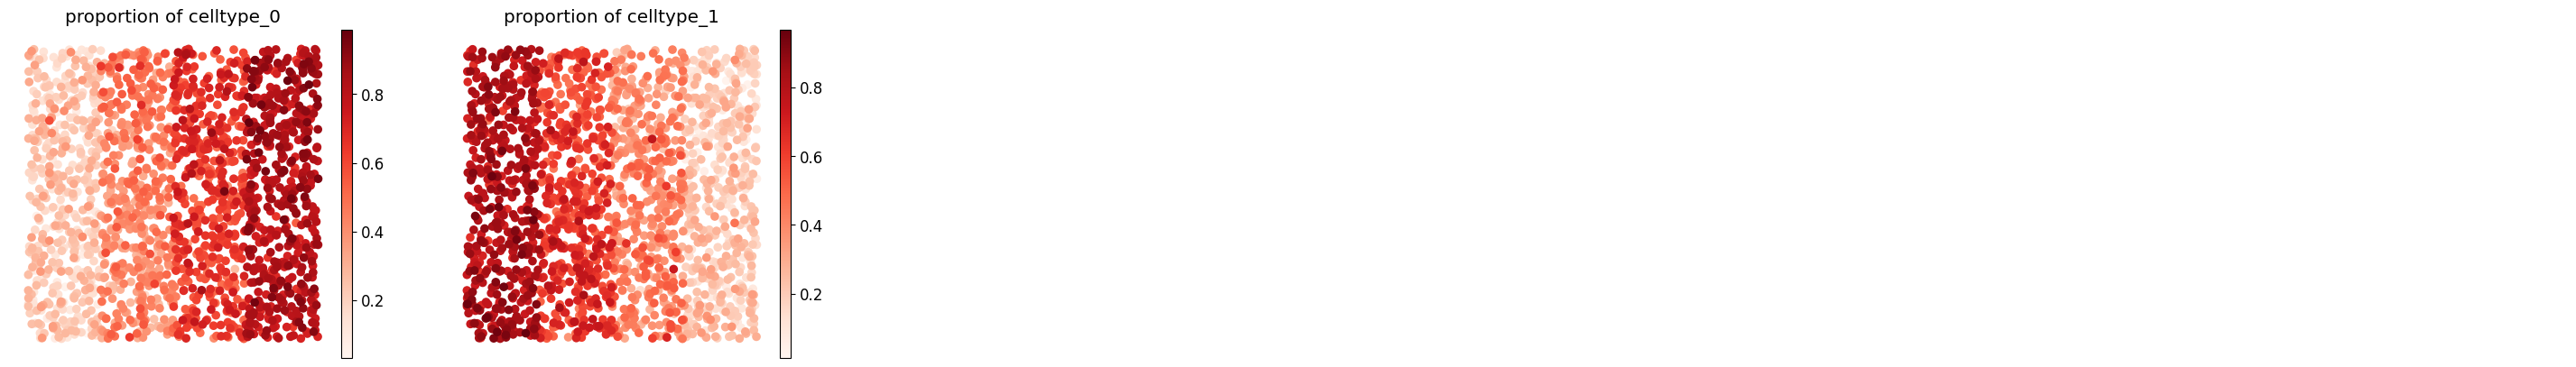

In [20]:
from MacSGP.vis import plot_spatial_ct
adata_st.obsm['spatial'][:, 1] = -adata_st.obsm['spatial'][:, 1]
plot_spatial_ct(adata_st, index='proportion',
                proportion_threshold=0.0, num_threshold=100, 
                cmap='Reds', 
                spot_size=0.03, 
                ncols=6)

In [33]:
model = MacSGP.model.Model(adata_st, adata_basis, n_layers=4, training_steps=3000)

model.train(step_interval=600)
adata_result_l4 = model.eval()

  0%|          | 11/3000 [00:00<00:29, 102.45it/s]

Step: 0, Loss: 1424.6738, d_loss: 1418.4396, f_loss: 62.3425, reg_loss: 0.0000


 21%|██        | 619/3000 [00:05<00:21, 111.43it/s]

Step: 600, Loss: 1407.1151, d_loss: 1396.7720, f_loss: 52.4960, reg_loss: 0.4589


 40%|████      | 1214/3000 [00:11<00:16, 106.46it/s]

...

 60%|██████    | 1812/3000 [00:16<00:10, 108.27it/s]

Step: 1800, Loss: 1403.0653, d_loss: 1393.2488, f_loss: 51.9225, reg_loss: 0.4166


 81%|████████  | 2417/3000 [00:22<00:05, 105.57it/s]

Step: 2400, Loss: 1402.9260, d_loss: 1393.1859, f_loss: 51.5419, reg_loss: 0.4131


100%|██████████| 3000/3000 [00:28<00:00, 106.85it/s]


In [34]:
model = MacSGP.model.Model(adata_st, adata_basis, n_layers=4, training_steps=3000, coef_fe=0)

model.train(step_interval=600)
adata_result_nofe = model.eval()

  1%|          | 22/3000 [00:00<00:28, 106.02it/s]

Step: 0, Loss: 1418.4396, d_loss: 1418.4396, f_loss: 62.3425, reg_loss: 0.0000


 21%|██        | 621/3000 [00:05<00:22, 105.26it/s]

Step: 600, Loss: 1400.7290, d_loss: 1395.6681, f_loss: 62.3482, reg_loss: 0.4559


 41%|████      | 1217/3000 [00:11<00:17, 104.06it/s]

...

 61%|██████    | 1822/3000 [00:17<00:11, 104.41it/s]

Step: 1800, Loss: 1397.6433, d_loss: 1393.0579, f_loss: 62.3497, reg_loss: 0.4131


 81%|████████  | 2417/3000 [00:22<00:05, 101.62it/s]

Step: 2400, Loss: 1397.4897, d_loss: 1392.8918, f_loss: 62.3481, reg_loss: 0.4142


100%|██████████| 3000/3000 [00:28<00:00, 106.00it/s]


In [13]:
model = MacSGP.model.Model(adata_st, adata_basis, n_layers=0, training_steps=3000)

model.train(step_interval=600)
adata_result_l0 = model.eval()

  2%|▏         | 53/3000 [00:00<00:11, 261.38it/s]

Step: 0, Loss: 1060.5167, d_loss: 1054.6382, f_loss: 58.7854, reg_loss: 0.0000


 22%|██▏       | 656/3000 [00:02<00:08, 262.47it/s]

Step: 600, Loss: 1052.1056, d_loss: 1043.6926, f_loss: 48.1979, reg_loss: 0.3237


 41%|████▏     | 1240/3000 [00:05<00:07, 250.85it/s]

...

 61%|██████    | 1830/3000 [00:07<00:04, 239.60it/s]

Step: 1800, Loss: 1050.0012, d_loss: 1042.1104, f_loss: 43.8214, reg_loss: 0.3161


 82%|████████▏ | 2448/3000 [00:10<00:02, 257.93it/s]

Step: 2400, Loss: 1049.7283, d_loss: 1041.8829, f_loss: 42.8114, reg_loss: 0.3211


100%|██████████| 3000/3000 [00:12<00:00, 240.18it/s]


Dropping cell types: []


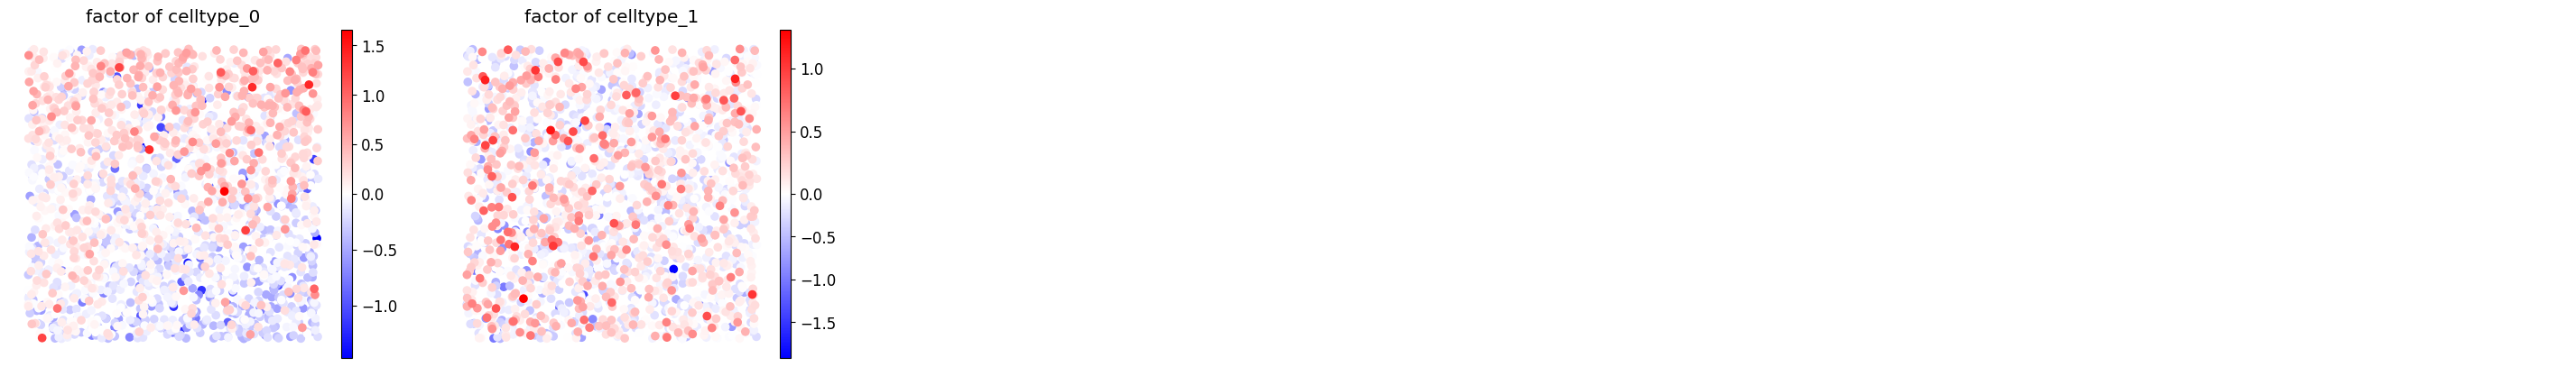

In [22]:
adata_result_nofe.obsm['spatial'][:, 1] = -adata_result_nofe.obsm['spatial'][:, 1]
plot_spatial_ct(adata_result_nofe, index='factor', reverse=False,
                proportion_threshold=0.0, num_threshold=100, 
                cmap='bwr', 
                spot_size=0.03, 
                ncols=6)

Dropping cell types: []


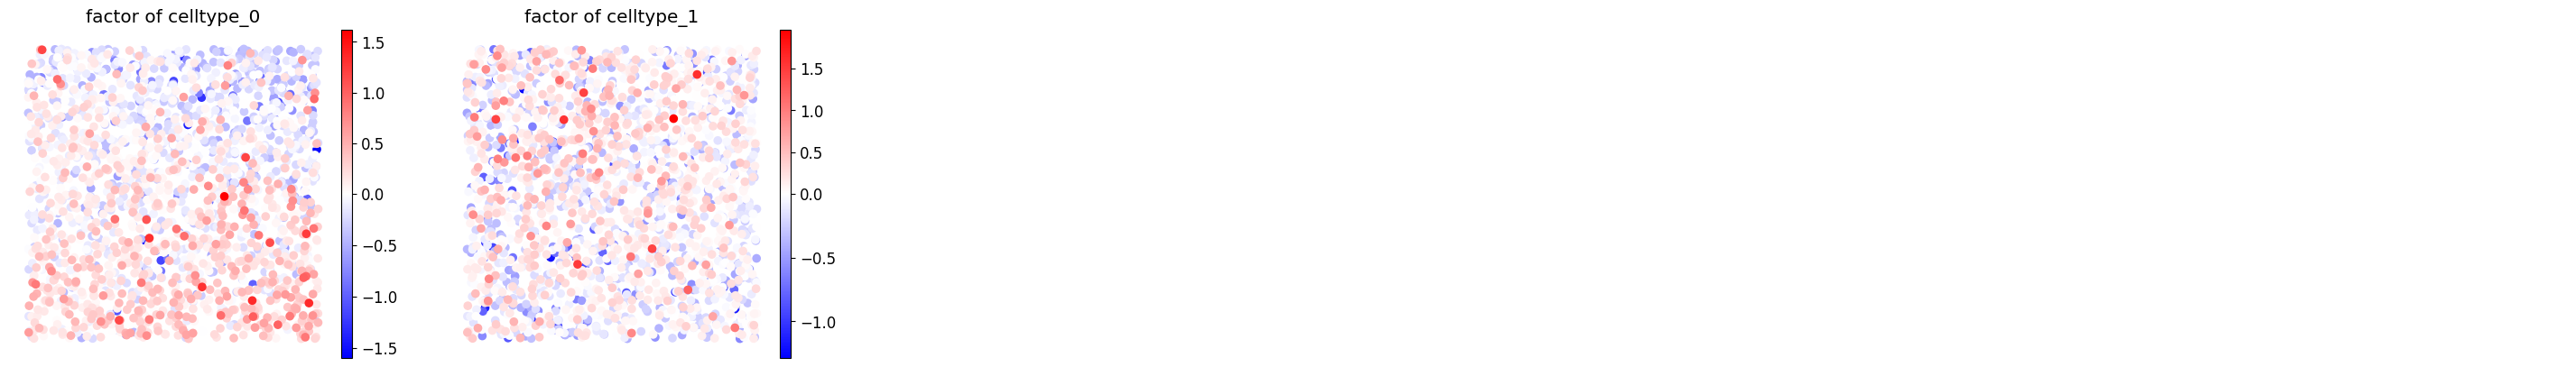

In [21]:
adata_result_l4.obsm['spatial'][:, 1] = -adata_result_l4.obsm['spatial'][:, 1]
plot_spatial_ct(adata_result_l4, index='factor', reverse=False,
                proportion_threshold=0.0, num_threshold=100, 
                cmap='bwr', 
                spot_size=0.03, 
                ncols=6)

Dropping cell types: []


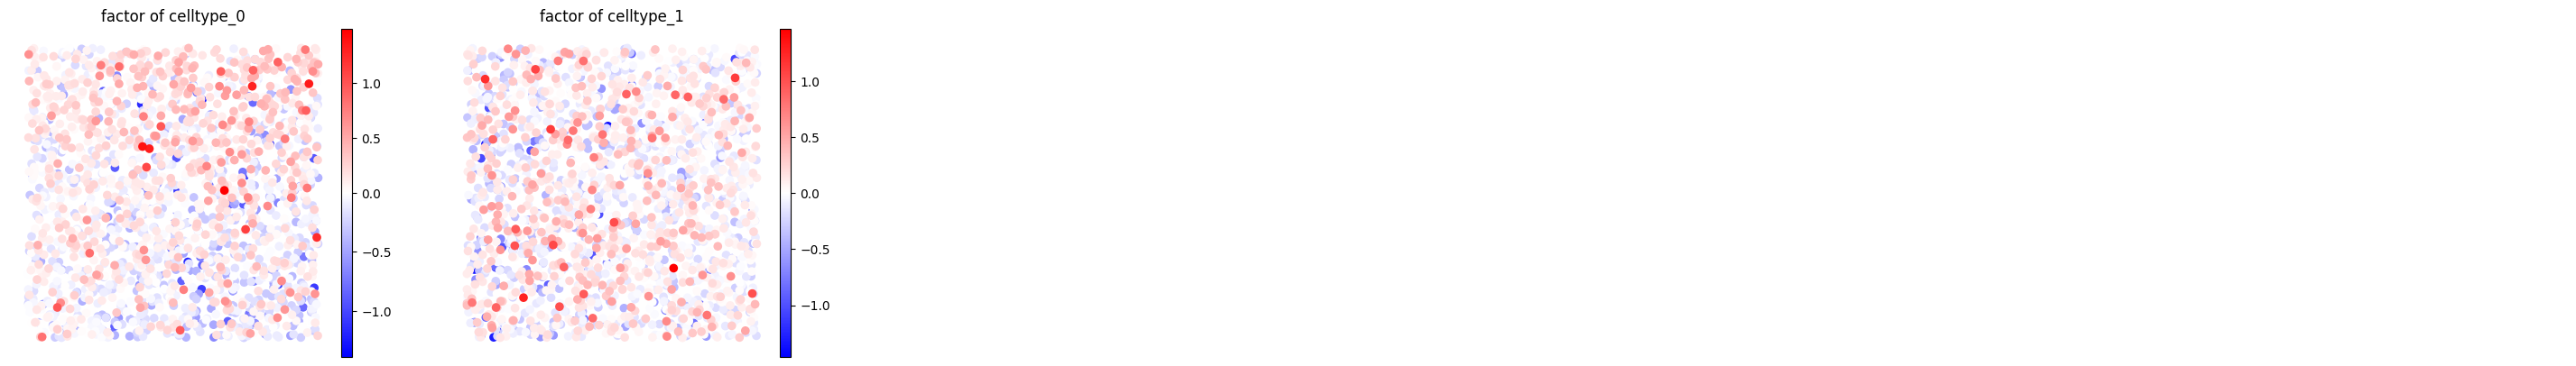

In [16]:
adata_result_l0.obsm['spatial'][:, 1] = -adata_result_l0.obsm['spatial'][:, 1]
plot_spatial_ct(adata_result_l0, index='factor', reverse=False,
                proportion_threshold=0.0, num_threshold=100, 
                cmap='bwr', 
                spot_size=0.03, 
                ncols=6)

In [17]:
import libpysal
import numpy as np
import esda
from libpysal.weights import KNN
# filter spots with low proportions
adata_result_l0_sub = adata_result_l0[adata_result_l0.obsm['proportion']['celltype_0'] > 0.0]
factor_true = adata_result_l0_sub.obsm['simulated_factor']
factor_macsgp = adata_result_l0_sub.obsm['factor']['celltype_0']
coords = adata_result_l0_sub.obsm['spatial']
w = KNN.from_array(coords, k=20)
w.transform = 'r'  # 行标准化
bi = esda.Moran_BV(factor_true, factor_macsgp, w, permutations=999)
print('I:', bi.I, 'p-value:', bi.p_sim)

loading_true = adata_result_l0_sub.varm['simulated_loading'][:, 0]
loading_macsgp = adata_result_l0_sub.varm['loading']['celltype_0']
cor = np.corrcoef(loading_true, loading_macsgp)[0, 1]
print('Correlation of loadings:', cor)

I: 0.2523845397554854 p-value: 0.001
Correlation of loadings: 0.2285981884651608


In [35]:
import libpysal
import numpy as np
import esda
from libpysal.weights import KNN
# filter spots with low proportions
adata_result_nofe_sub = adata_result_nofe[adata_result_nofe.obsm['proportion']['celltype_0'] > 0.0]
factor_true = adata_result_nofe_sub.obsm['simulated_factor']
factor_macsgp = adata_result_nofe_sub.obsm['factor']['celltype_0']
coords = adata_result_nofe_sub.obsm['spatial']
w = KNN.from_array(coords, k=20)
w.transform = 'r'  # 行标准化
bi = esda.Moran_BV(factor_true, factor_macsgp, w, permutations=999)
print('I:', bi.I, 'p-value:', bi.p_sim)

loading_true = adata_result_nofe_sub.varm['simulated_loading'][:, 0]
loading_macsgp = adata_result_nofe_sub.varm['loading']['celltype_0']
cor = np.corrcoef(loading_true, loading_macsgp)[0, 1]
print('Correlation of loadings:', cor)

I: 0.4109961069050603 p-value: 0.001
Correlation of loadings: 0.38186949354392835


In [36]:
import libpysal
import numpy as np
import esda
from libpysal.weights import KNN
adata_result_l4_sub = adata_result_l4[adata_result_l4.obsm['proportion']['celltype_0'] > 0.0]
factor_true = adata_result_l4_sub.obsm['simulated_factor']
factor_macsgp = adata_result_l4_sub.obsm['factor']['celltype_0']
coords = adata_result_l4_sub.obsm['spatial']
w = KNN.from_array(coords, k=20)
w.transform = 'r'  # 行标准化
bi = esda.Moran_BV(factor_true, factor_macsgp, w, permutations=999)
print('I:', bi.I, 'p-value:', bi.p_sim)

loading_true = adata_result_l4_sub.varm['simulated_loading'][:, 0]
loading_macsgp = adata_result_l4_sub.varm['loading']['celltype_0']
cor = np.corrcoef(loading_true, loading_macsgp)[0, 1]
print('Correlation of loadings:', cor)

I: 0.40246702353841324 p-value: 0.001
Correlation of loadings: 0.36855443074355165


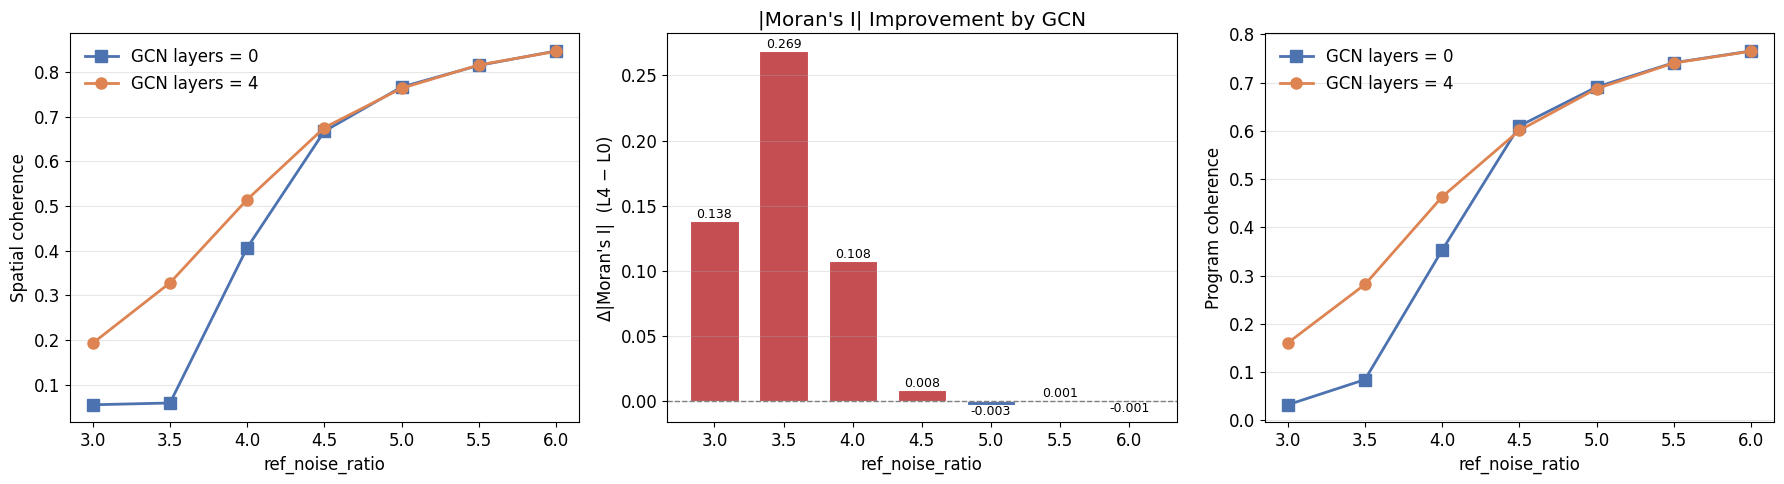

In [6]:
# plot_ablation.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

#matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 12

# ============================================================
# 读取结果
# ============================================================
BASE_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/ablation'
df_results = pd.read_csv(f'{BASE_PATH}/ablation_results_lib800.csv')

# 对 loading_corr 和 moran_I 取绝对值
df_results['loading_corr_abs'] = df_results['loading_corr'].abs()
df_results['moran_I_abs'] = df_results['moran_I'].abs()

ref_noise_ratios = sorted(df_results['ref_noise_ratio'].unique())

# ============================================================
# 画图
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------- 图1: |Moran's I| 折线对比 ----------
ax = axes[0]
for n_layers, marker, color, label in [(0, 's', '#4C72B0', 'GCN layers = 0'),
                                        (4, 'o', '#DD8452', 'GCN layers = 4')]:
    sub = df_results[df_results['n_layers'] == n_layers]
    ax.plot(sub['ref_noise_ratio'], sub['moran_I_abs'],
            marker=marker, color=color, linewidth=2, markersize=8, label=label)

ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel("Spatial coherence")
ax.set_title("")
ax.legend(frameon=False)
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

# ---------- 图2: Δ|Moran's I| 柱状图 ----------
ax = axes[1]
pivot_moran = df_results.pivot(index='ref_noise_ratio', columns='n_layers', values='moran_I_abs')
diff_moran = pivot_moran[4] - pivot_moran[0]

colors = ['#C44E52' if d > 0 else '#4C72B0' for d in diff_moran.values]
bars = ax.bar(diff_moran.index, diff_moran.values, width=0.35,
              color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel("Δ|Moran's I|  (L4 − L0)")
ax.set_title("|Moran's I| Improvement by GCN")
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, diff_moran.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.3f}', ha='center',
            va='bottom' if val >= 0 else 'top', fontsize=9)

# ---------- 图3: |Loading Correlation| 折线对比 ----------
ax = axes[2]
for n_layers, marker, color, label in [(0, 's', '#4C72B0', 'GCN layers = 0'),
                                        (4, 'o', '#DD8452', 'GCN layers = 4')]:
    sub = df_results[df_results['n_layers'] == n_layers]
    ax.plot(sub['ref_noise_ratio'], sub['loading_corr_abs'],
            marker=marker, color=color, linewidth=2, markersize=8, label=label)

ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel('Program coherence')
ax.set_title('')
ax.legend(frameon=False)
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig(f'{BASE_PATH}/ablation_moran_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{BASE_PATH}/ablation_moran_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
BASE_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/ablation'
library_size = 1000
v = 4
df_results = pd.read_csv(
    os.path.join(BASE_PATH, f'ablation_results_all_seeds_lib{library_size}_v{v}.csv')
)
# df_results = pd.read_csv(
#     os.path.join(BASE_PATH, f'ablation_results_lib{library_size}_v{v}.csv')
# )
# df_results = pd.read_csv(
#     os.path.join(BASE_PATH, f'ablation_results_lib{library_size}.csv')
# )
df_results['moran_I_abs'] = df_results['moran_I'].abs()
df_results['loading_corr_abs'] = df_results['loading_corr'].abs()

# ============================================================
# 按 (ref_noise_ratio, n_layers) 汇总 mean ± std（绝对值）
# ============================================================
df_summary = (
    df_results
    .groupby(['ref_noise_ratio', 'n_layers'])
    .agg(
        moran_I_abs_mean=('moran_I_abs', 'mean'),
        moran_I_abs_std=('moran_I_abs', 'std'),
        moran_p_mean=('moran_p', 'mean'),
        loading_corr_abs_mean=('loading_corr_abs', 'mean'),
        loading_corr_abs_std=('loading_corr_abs', 'std'),
    )
    .reset_index()
)
df_summary.to_csv(
    os.path.join(BASE_PATH, f'ablation_results_summary_lib{library_size}_v{v}.csv'),
    index=False
)

print(f"\n{'='*60}")
print("汇总结果 (|mean| ± std over 5 seeds):")
print(f"{'='*60}")
print(df_summary.to_string(index=False))

# ---------- |Moran's I| 对比表格 ----------
print(f"\n{'='*60}")
print("|Moran's I| 对比 (L0 vs L4, mean ± std):")
print(f"{'='*60}")

pivot_moran_mean = df_summary.pivot(
    index='ref_noise_ratio', columns='n_layers', values='moran_I_abs_mean'
)
pivot_moran_std = df_summary.pivot(
    index='ref_noise_ratio', columns='n_layers', values='moran_I_abs_std'
)

pivot_moran_display = pd.DataFrame(index=pivot_moran_mean.index)
for c in sorted(pivot_moran_mean.columns):
    pivot_moran_display[f'L{c}'] = [
        f"{m:.4f}±{s:.4f}"
        for m, s in zip(pivot_moran_mean[c], pivot_moran_std[c])
    ]
pivot_moran_display['diff_mean (L4-L0)'] = (
    pivot_moran_mean[4] - pivot_moran_mean[0]
)
print(pivot_moran_display.to_string())

# ---------- |Loading Correlation| 对比表格 ----------
print(f"\n|Loading Correlation| 对比 (L0 vs L4, mean ± std):")
print(f"{'='*60}")

pivot_cor_mean = df_summary.pivot(
    index='ref_noise_ratio', columns='n_layers', values='loading_corr_abs_mean'
)
pivot_cor_std = df_summary.pivot(
    index='ref_noise_ratio', columns='n_layers', values='loading_corr_abs_std'
)

pivot_cor_display = pd.DataFrame(index=pivot_cor_mean.index)
for c in sorted(pivot_cor_mean.columns):
    pivot_cor_display[f'L{c}'] = [
        f"{m:.4f}±{s:.4f}"
        for m, s in zip(pivot_cor_mean[c], pivot_cor_std[c])
    ]
pivot_cor_display['diff_mean (L4-L0)'] = (
    pivot_cor_mean[4] - pivot_cor_mean[0]
)
print(pivot_cor_display.to_string())


汇总结果 (|mean| ± std over 5 seeds):
 ref_noise_ratio  n_layers  moran_I_abs_mean  moran_I_abs_std  moran_p_mean  loading_corr_abs_mean  loading_corr_abs_std
             3.0         0          0.040350         0.010811         0.048               0.038419              0.025504
             3.0         4          0.079971         0.045719         0.070               0.061821              0.042506
             3.5         0          0.038808         0.030611         0.155               0.032854              0.027156
             3.5         4          0.192633         0.048180         0.001               0.172253              0.039284
             4.0         0          0.171238         0.095369         0.001               0.160086              0.066768
             4.0         4          0.313824         0.075523         0.001               0.306829              0.058577
             4.5         0          0.493842         0.052735         0.001               0.461657              0.0407

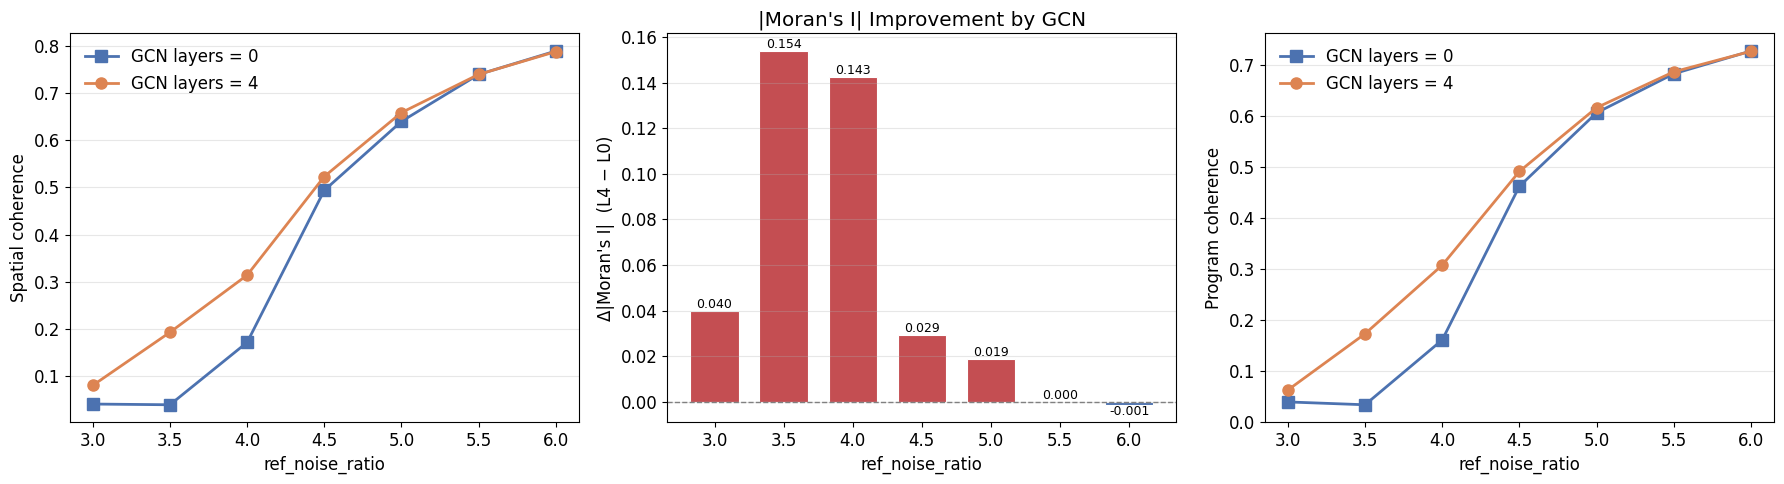

In [18]:
# plot_ablation.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

#matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 12

# ============================================================
# 读取结果
# ============================================================
BASE_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/ablation'
# df_results = pd.read_csv(f'{BASE_PATH}/ablation_results_lib800.csv')

# # 对 loading_corr 和 moran_I 取绝对值
# df_results['loading_corr_abs'] = df_results['loading_corr'].abs()
# df_results['moran_I_abs'] = df_results['moran_I'].abs()

ref_noise_ratios = sorted(df_results['ref_noise_ratio'].unique())

# ============================================================
# 画图
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------- 图1: |Moran's I| 折线对比 ----------
ax = axes[0]
for n_layers, marker, color, label in [(0, 's', '#4C72B0', 'GCN layers = 0'),
                                        (4, 'o', '#DD8452', 'GCN layers = 4')]:
    sub = df_summary[df_summary['n_layers'] == n_layers]
    ax.plot(sub['ref_noise_ratio'], sub['moran_I_abs_mean'],
            marker=marker, color=color, linewidth=2, markersize=8, label=label)

ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel("Spatial coherence")
ax.set_title("")
ax.legend(frameon=False)
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

# ---------- 图2: Δ|Moran's I| 柱状图 ----------
ax = axes[1]
pivot_moran = df_summary.pivot(index='ref_noise_ratio', columns='n_layers', values='moran_I_abs_mean')
diff_moran = pivot_moran[4] - pivot_moran[0]

colors = ['#C44E52' if d > 0 else '#4C72B0' for d in diff_moran.values]
bars = ax.bar(diff_moran.index, diff_moran.values, width=0.35,
              color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel("Δ|Moran's I|  (L4 − L0)")
ax.set_title("|Moran's I| Improvement by GCN")
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, diff_moran.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.3f}', ha='center',
            va='bottom' if val >= 0 else 'top', fontsize=9)

# ---------- 图3: |Loading Correlation| 折线对比 ----------
ax = axes[2]
for n_layers, marker, color, label in [(0, 's', '#4C72B0', 'GCN layers = 0'),
                                        (4, 'o', '#DD8452', 'GCN layers = 4')]:
    sub = df_summary[df_summary['n_layers'] == n_layers]
    ax.plot(sub['ref_noise_ratio'], sub['loading_corr_abs_mean'],
            marker=marker, color=color, linewidth=2, markersize=8, label=label)

ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel('Program coherence')
ax.set_title('')
ax.legend(frameon=False)
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig(f'{BASE_PATH}/ablation_moran_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{BASE_PATH}/ablation_moran_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

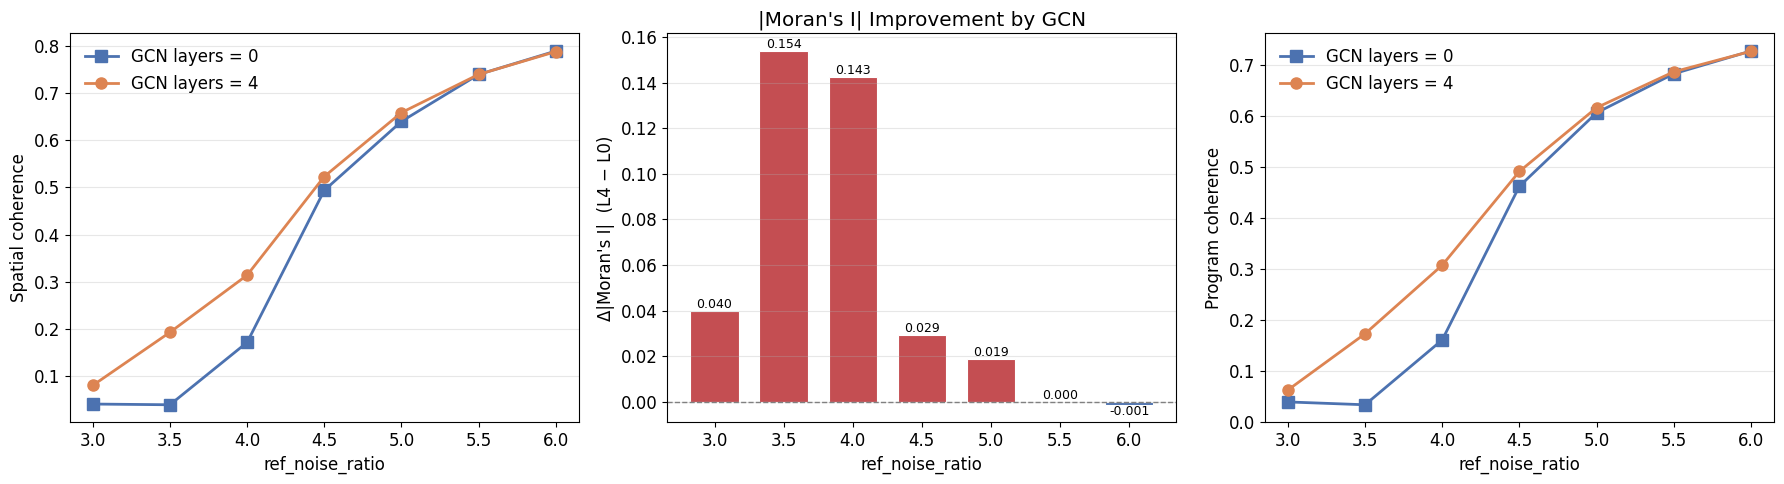

In [13]:
# plot_ablation.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

#matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 12

# ============================================================
# 读取结果
# ============================================================
BASE_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/ablation'
# df_results = pd.read_csv(f'{BASE_PATH}/ablation_results_lib800.csv')

# # 对 loading_corr 和 moran_I 取绝对值
# df_results['loading_corr_abs'] = df_results['loading_corr'].abs()
# df_results['moran_I_abs'] = df_results['moran_I'].abs()

ref_noise_ratios = sorted(df_results['ref_noise_ratio'].unique())

# ============================================================
# 画图
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------- 图1: |Moran's I| 折线对比 ----------
ax = axes[0]
for n_layers, marker, color, label in [(0, 's', '#4C72B0', 'GCN layers = 0'),
                                        (4, 'o', '#DD8452', 'GCN layers = 4')]:
    sub = df_summary[df_summary['n_layers'] == n_layers]
    ax.plot(sub['ref_noise_ratio'], sub['moran_I_abs_mean'],
            marker=marker, color=color, linewidth=2, markersize=8, label=label)

ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel("Spatial coherence")
ax.set_title("")
ax.legend(frameon=False)
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

# ---------- 图2: Δ|Moran's I| 柱状图 ----------
ax = axes[1]
pivot_moran = df_summary.pivot(index='ref_noise_ratio', columns='n_layers', values='moran_I_abs_mean')
diff_moran = pivot_moran[4] - pivot_moran[0]

colors = ['#C44E52' if d > 0 else '#4C72B0' for d in diff_moran.values]
bars = ax.bar(diff_moran.index, diff_moran.values, width=0.35,
              color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel("Δ|Moran's I|  (L4 − L0)")
ax.set_title("|Moran's I| Improvement by GCN")
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, diff_moran.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.3f}', ha='center',
            va='bottom' if val >= 0 else 'top', fontsize=9)

# ---------- 图3: |Loading Correlation| 折线对比 ----------
ax = axes[2]
for n_layers, marker, color, label in [(0, 's', '#4C72B0', 'GCN layers = 0'),
                                        (4, 'o', '#DD8452', 'GCN layers = 4')]:
    sub = df_summary[df_summary['n_layers'] == n_layers]
    ax.plot(sub['ref_noise_ratio'], sub['loading_corr_abs_mean'],
            marker=marker, color=color, linewidth=2, markersize=8, label=label)

ax.set_xlabel('ref_noise_ratio')
ax.set_ylabel('Program coherence')
ax.set_title('')
ax.legend(frameon=False)
ax.set_xticks(ref_noise_ratios)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig(f'{BASE_PATH}/ablation_moran_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{BASE_PATH}/ablation_moran_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:

# ============================================================
# Load 2x2 ablation results (GNN × RAE)
# ============================================================
import pandas as pd
import numpy as np
import os

BASE_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/ablation'
library_size = 1000
v = 4

df_rae_all = pd.read_csv(
    os.path.join(BASE_PATH, f'ablation_graph_rae_all_seeds_lib{library_size}_v{v}.csv')
)
df_rae_all['moran_I_abs']      = df_rae_all['moran_I'].abs()
df_rae_all['loading_corr_abs'] = df_rae_all['loading_corr'].abs()

df_rae_summary = pd.read_csv(
    os.path.join(BASE_PATH, f'ablation_graph_rae_summary_lib{library_size}_v{v}.csv')
)

noise_levels = sorted(df_rae_summary['ref_noise_ratio'].unique())
print(df_rae_summary.to_string(index=False))


 ref_noise_ratio    label  moran_I_abs_mean  moran_I_abs_std  moran_p_mean  loading_corr_abs_mean  loading_corr_abs_std
             3.0   L0_RAE          0.040350         0.010811        0.0506               0.038419              0.025504
             3.0 L0_noRAE          0.041059         0.021008        0.0744               0.031299              0.020932
             3.0   L4_RAE          0.079971         0.045719        0.0658               0.061821              0.042506
             3.0 L4_noRAE          0.033509         0.017743        0.1154               0.040440              0.015981
             3.5   L0_RAE          0.038808         0.030611        0.1444               0.032854              0.027156
             3.5 L0_noRAE          0.048362         0.026534        0.0656               0.035121              0.013252
             3.5   L4_RAE          0.192633         0.048180        0.0010               0.172253              0.039284
             3.5 L4_noRAE          0.148

In [2]:
# Nature Communications style
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'       : 'Helvetica',
    'font.size'         : 7,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 7,
    'xtick.labelsize'   : 6.5,
    'ytick.labelsize'   : 6.5,
    'axes.linewidth'    : 0.5,
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'xtick.major.size'  : 2.5,
    'ytick.major.size'  : 2.5,
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'savefig.dpi'       : 300,
    'figure.dpi'        : 150,
})

In [3]:
ref_noise_ratios_show = [3.5,4.0,4.5,5.0,5.5]

In [4]:
df_rae_summary_show = df_rae_summary[df_rae_summary['ref_noise_ratio'].isin(ref_noise_ratios_show)]

In [5]:
noise_levels = ref_noise_ratios_show

Saved: /import/home2/share/yqzeng/MacSGP/experiments/ablation/ablation_graph_rae_lib1000_v4.pdf / .png


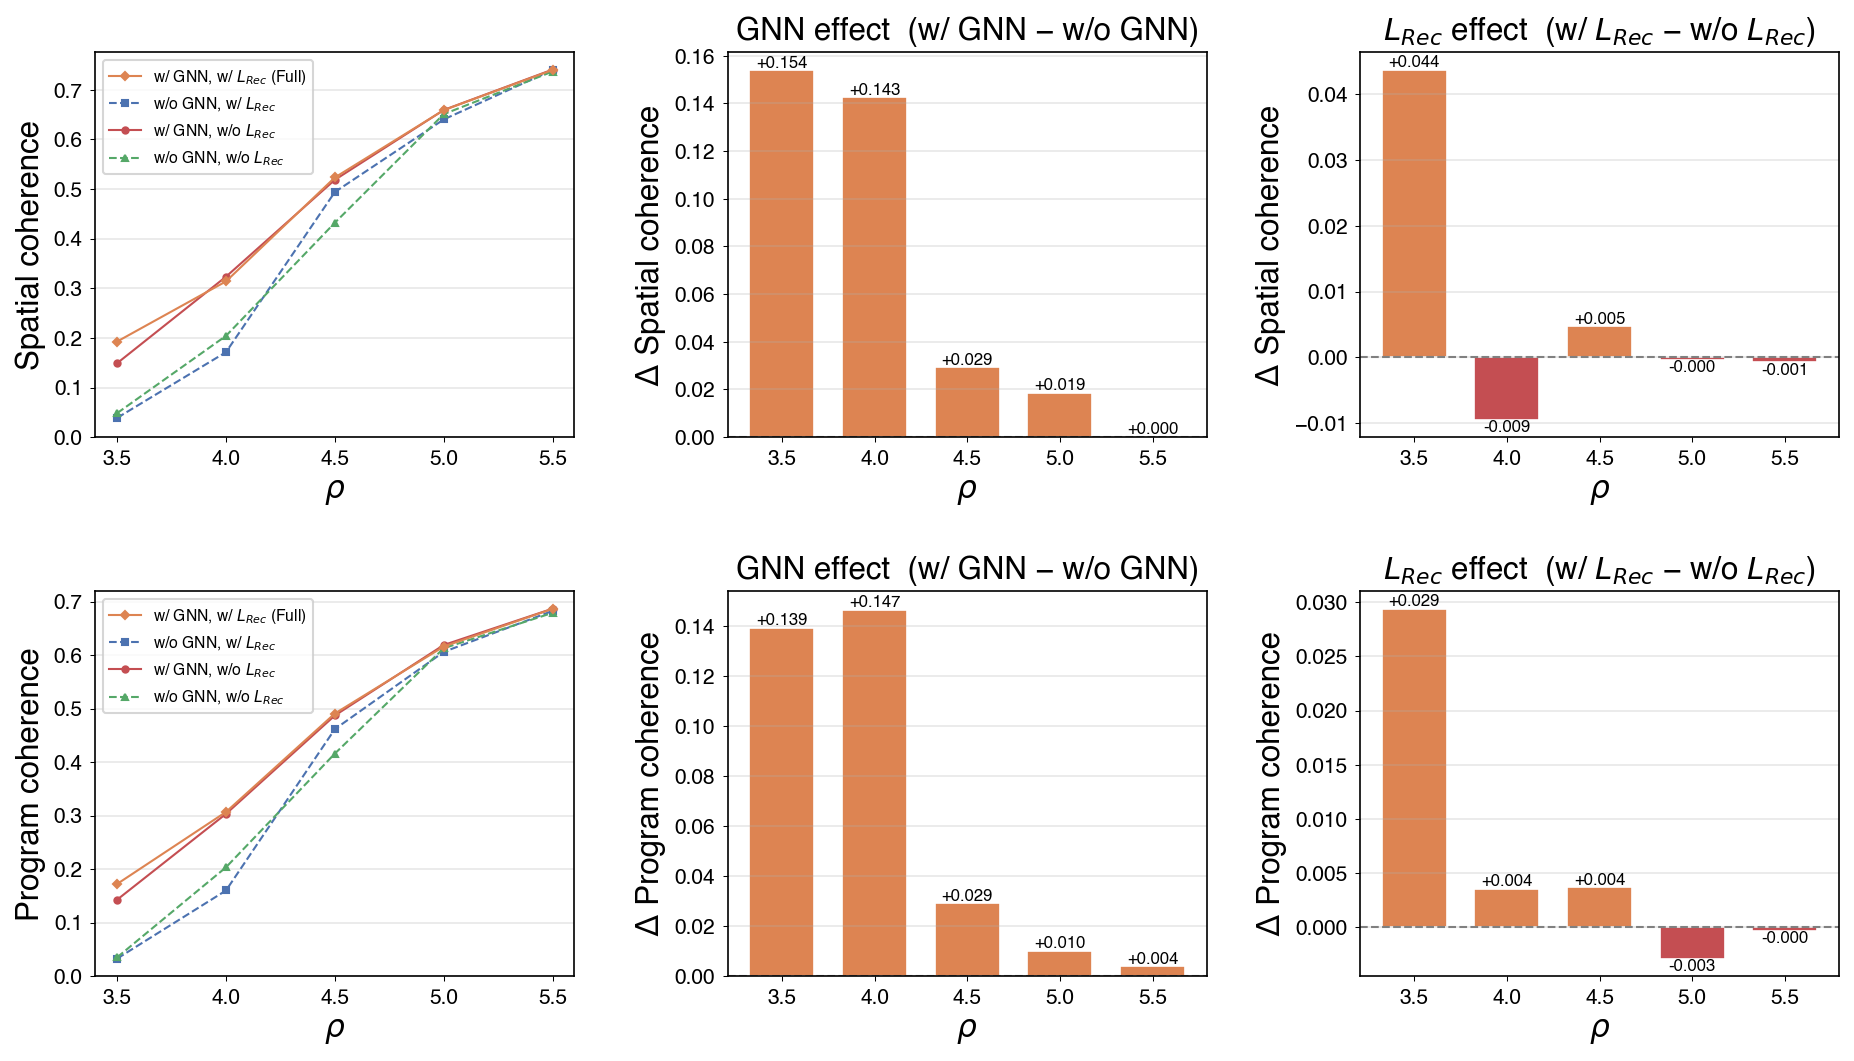

In [14]:

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.linewidth'] = 0.8

STYLES = {
    'L4_noRAE': {'color': '#C44E52', 'marker': 'o', 'ls': '-',  'label': 'w/ GNN, w/o RAE'},
    'L0_RAE':   {'color': '#4C72B0', 'marker': 's', 'ls': '--', 'label': 'w/o GNN, w/ RAE'},
    'L0_noRAE': {'color': '#55A868', 'marker': '^', 'ls': '--', 'label': 'w/o GNN, w/o RAE'},
    'L4_RAE':   {'color': '#DD8452', 'marker': 'D', 'ls': '-',  'label': 'w/ GNN, w/ RAE (Full)'},
}
#LABEL_ORDER = ['L4_RAE', 'L0_RAE', 'L4_noRAE', 'L0_noRAE']
LABEL_ORDER = ['L4_noRAE', 'L0_RAE', 'L0_noRAE', 'L4_RAE']

METRICS = [
    ('moran_I_abs_mean',      'moran_I_abs_std',      "Spatial coherence",        "Spatial coherence"),
    ('loading_corr_abs_mean', 'loading_corr_abs_std', "Program coherence",    "Program coherence"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace=0.40, wspace=0.32)

for row, (col_mean, col_std, metric_short, metric_long) in enumerate(METRICS):
    pivot = df_rae_summary_show.pivot(index='ref_noise_ratio', columns='label', values=col_mean)

    # ---- (a/d) All 4 conditions ----
    ax = axes[row, 0]
    for lbl in LABEL_ORDER:
        sub = df_rae_summary_show[df_rae_summary_show['label'] == lbl].sort_values('ref_noise_ratio')
        st  = STYLES[lbl]
        mean = sub[col_mean].values
        std  = sub[col_std].values
        ax.plot(sub['ref_noise_ratio'], mean,
                marker=st['marker'], color=st['color'], ls=st['ls'],
                linewidth=1.0, markersize=3, label=st['label'])
        # ax.fill_between(sub['ref_noise_ratio'], mean - std, mean + std,
        #                 color=st['color'], alpha=0.10)
    ax.set_xlabel(r'$\rho$', fontsize=15)
    ax.set_ylabel(metric_short, fontsize=15)
    #ax.set_title(f'({chr(97 + row*3)}) {metric_long}: all conditions', fontsize=15)
    #ax.legend(fontsize=8, frameon=False)
    # 画完所有线之后
    handles, labels = ax.get_legend_handles_labels()

    # 构建 label -> handle 的映射
    handle_dict = dict(zip(labels, handles))

    # 按你想要的顺序排列
    desired_order = [
        'w/ GNN, w/ RAE (Full)',   # 第一行
        'w/o GNN, w/ RAE',
        'w/ GNN, w/o RAE',
        'w/o GNN, w/o RAE',        # 最后一行
    ]
    new_labels = [
        r'w/ GNN, w/ $L_{Rec}$ (Full)',   # 第一行
        r'w/o GNN, w/ $L_{Rec}$',
        r'w/ GNN, w/o $L_{Rec}$',
        r'w/o GNN, w/o $L_{Rec}$',        # 最后一行
    ]

    ordered_handles = [handle_dict[l] for l in desired_order]
    ax.legend(ordered_handles, desired_order, fontsize=7.5)
    # reset labels for legends [1,2,3,4] -> [a,b,c,d]
    legend = ax.get_legend()
    for text, new_label in zip(legend.get_texts(), new_labels):
        text.set_text(new_label)

    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

    # ---- (b/e) Δ GNN = L4_RAE − L0_RAE ----
    ax = axes[row, 1]
    delta = pivot['L4_RAE'] - pivot['L0_RAE']
    colors = ['#DD8452' if d > 0 else '#4C72B0' for d in delta.values]
    bars = ax.bar(delta.index, delta.values, width=0.35,
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel(r'$\rho$', fontsize=15)
    ax.set_ylabel(f'Δ {metric_short}', fontsize=15)
    ax.set_title(r'GNN effect  (w/ GNN − w/o GNN)', fontsize=15)
    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, delta.values):
        offset = 0.000 if val >= 0 else -0.000
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{val:+.3f}', ha='center',
                va='bottom' if val >= 0 else 'top', fontsize=8)

    # ---- (c/f) Δ RAE = L4_RAE − L4_noRAE ----
    ax = axes[row, 2]
    delta = pivot['L4_RAE'] - pivot['L4_noRAE']
    colors = ['#DD8452' if d > 0 else '#C44E52' for d in delta.values]
    bars = ax.bar(delta.index, delta.values, width=0.35,
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel(r'$\rho$', fontsize=15)
    ax.set_ylabel(f'Δ {metric_short}', fontsize=15)
    ax.set_title(r'$L_{Rec}$ effect  (w/ $L_{Rec}$ − w/o $L_{Rec}$)', fontsize=15)
    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, delta.values):
        offset = 0.000 if val >= 0 else -0.000
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{val:+.3f}', ha='center',
                va='bottom' if val >= 0 else 'top', fontsize=8)

out_prefix = os.path.join(BASE_PATH, f'ablation_graph_rae_lib{library_size}_v{v}')
# plt.savefig(f'{out_prefix}.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{out_prefix}.png', dpi=300, bbox_inches='tight')
print(f"Saved: {out_prefix}.pdf / .png")  
plt.show()


Saved: /import/home2/share/yqzeng/MacSGP/experiments/ablation/ablation_graph_rae_lib1000_v4.pdf / .png


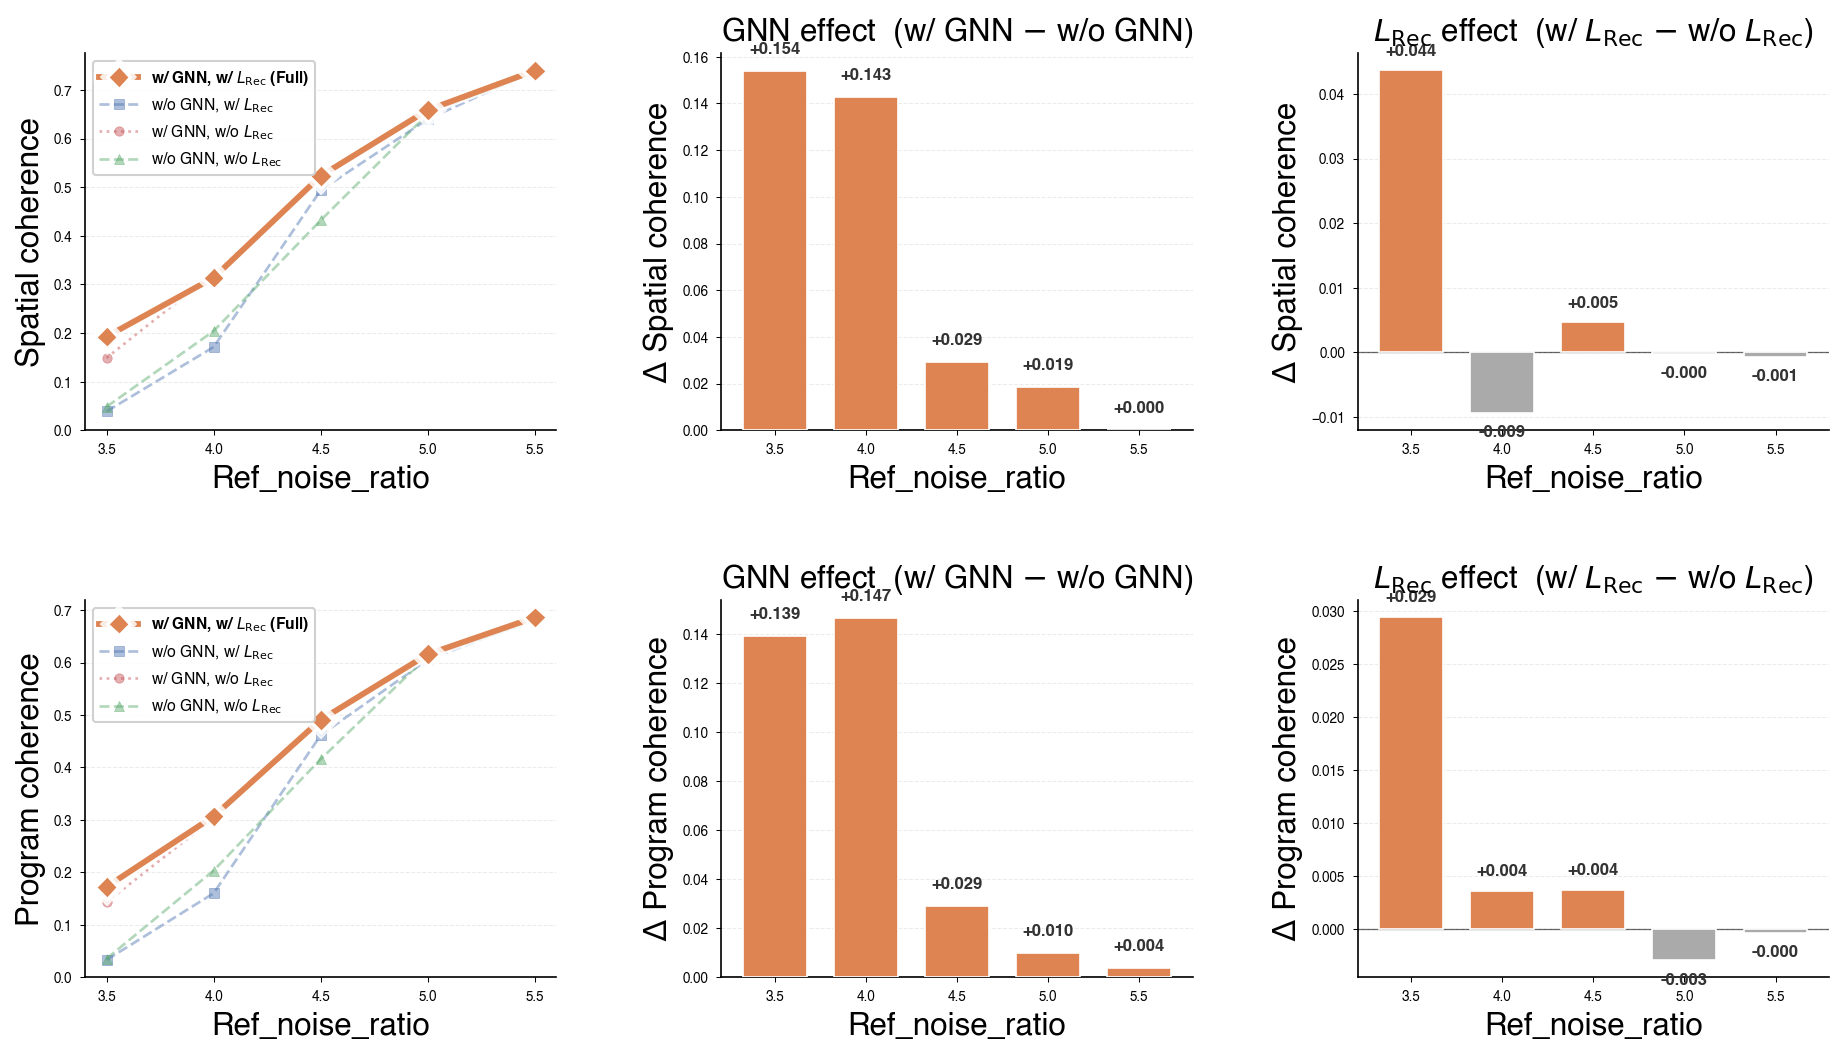

In [30]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

matplotlib.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':        11,
    'axes.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right': False,
})

# ── 样式：Full model 粗+大+不透明，其他淡化 ──
STYLES = {
    'L4_noRAE': {'color': '#C44E52', 'marker': 'o', 'ls': ':',
                 'lw': 1.3, 'ms': 4.5, 'alpha': 0.45, 'zorder': 2},
    'L0_RAE':   {'color': '#4C72B0', 'marker': 's', 'ls': '--',
                 'lw': 1.3, 'ms': 4.5, 'alpha': 0.45, 'zorder': 2},
    'L0_noRAE': {'color': '#55A868', 'marker': '^', 'ls': '--',
                 'lw': 1.3, 'ms': 4.5, 'alpha': 0.45, 'zorder': 2},
    # ★ Full model：最粗最大，完全不透明
    'L4_RAE':   {'color': '#DD8452', 'marker': 'D', 'ls': '-',
                 'lw': 2.8, 'ms': 8,   'alpha': 1.0,  'zorder': 5},
}

# 画图顺序：Full model 最后画 → 在最上层
LABEL_ORDER = ['L4_noRAE', 'L0_RAE', 'L0_noRAE', 'L4_RAE']

# Legend 显示顺序 & 显示名称
LEGEND_ORDER = ['L4_RAE', 'L0_RAE', 'L4_noRAE', 'L0_noRAE']
LEGEND_NAMES = {
    'L4_RAE':   r'w/ GNN, w/ $L_{\mathrm{Rec}}$ (Full)',
    'L0_RAE':   r'w/o GNN, w/ $L_{\mathrm{Rec}}$',
    'L4_noRAE': r'w/ GNN, w/o $L_{\mathrm{Rec}}$',
    'L0_noRAE': r'w/o GNN, w/o $L_{\mathrm{Rec}}$',
}

METRICS = [
    ('moran_I_abs_mean',      'moran_I_abs_std',      "Spatial coherence",  "Spatial coherence"),
    ('loading_corr_abs_mean', 'loading_corr_abs_std',  "Program coherence",  "Program coherence"),
]

BAR_POS = '#DD8452'
BAR_NEG = '#AAAAAA'

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace=0.45, wspace=0.35)

for row, (col_mean, col_std, metric_short, metric_long) in enumerate(METRICS):
    pivot = df_rae_summary_show.pivot(
        index='ref_noise_ratio', columns='label', values=col_mean)

    # ======== 左图：折线 ========
    ax = axes[row, 0]
    legend_handles = {}

    for lbl in LABEL_ORDER:
        sub = df_rae_summary_show[df_rae_summary_show['label'] == lbl] \
                                  .sort_values('ref_noise_ratio')
        st = STYLES[lbl]
        mean = sub[col_mean].values
        x    = sub['ref_noise_ratio'].values
        is_full = (lbl == 'L4_RAE')

        line, = ax.plot(
            x, mean,
            marker=st['marker'], color=st['color'], ls=st['ls'],
            linewidth=st['lw'], markersize=st['ms'],
            alpha=st['alpha'], zorder=st['zorder'],
            # Full model marker 加白色边框，更醒目
            markeredgecolor='white' if is_full else st['color'],
            markeredgewidth=1.5 if is_full else 0.4,
        )
        # ★ Full model 白色光晕 → 和重合线物理分离
        if is_full:
            line.set_path_effects([
                pe.Stroke(linewidth=5, foreground='white', alpha=0.85),
                pe.Normal(),
            ])
        legend_handles[lbl] = line

    ax.set_xlabel('Ref_noise_ratio', fontsize=15)
    ax.set_ylabel(metric_short, fontsize=15)
    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.25, ls='--', lw=0.5)
    ax.set_ylim(bottom=0)

    # ── legend：自定义顺序 + 名称，一步到位 ──
    leg = ax.legend(
        [legend_handles[k] for k in LEGEND_ORDER],
        [LEGEND_NAMES[k]   for k in LEGEND_ORDER],
        fontsize=7.5, frameon=True, fancybox=True,
        framealpha=0.9, edgecolor='#CCCCCC',
        loc='upper left', handlelength=2.5,
    )
    leg.get_texts()[0].set_fontweight('bold')  # Full model 加粗

    # ======== 中图：Δ GNN ========
    ax = axes[row, 1]
    delta = pivot['L4_RAE'] - pivot['L0_RAE']
    colors = [BAR_POS if d > 0 else BAR_NEG for d in delta.values]
    bars = ax.bar(delta.index, delta.values, width=0.35,
                  color=colors, edgecolor='white', linewidth=0.8, zorder=3)
    ax.axhline(0, color='#555555', ls='-', lw=0.6, zorder=1)
    ax.set_xlabel('Ref_noise_ratio', fontsize=15)
    ax.set_ylabel(f'Δ {metric_short}', fontsize=15)
    ax.set_title(r'GNN effect  (w/ GNN $-$ w/o GNN)', fontsize=15)
    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.25, ls='--', lw=0.5)
    _ymax = max(abs(delta.values).max(), 1e-6)
    for bar, val in zip(bars, delta.values):
        offset = _ymax * 0.04 * (1 if val >= 0 else -1)
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{val:+.3f}', ha='center',
                va='bottom' if val >= 0 else 'top',
                fontsize=8, fontweight='bold', color='#333333')

    # ======== 右图：Δ L_Rec ========
    ax = axes[row, 2]
    delta = pivot['L4_RAE'] - pivot['L4_noRAE']
    colors = [BAR_POS if d > 0 else BAR_NEG for d in delta.values]
    bars = ax.bar(delta.index, delta.values, width=0.35,
                  color=colors, edgecolor='white', linewidth=0.8, zorder=3)
    ax.axhline(0, color='#555555', ls='-', lw=0.6, zorder=1)
    ax.set_xlabel('Ref_noise_ratio', fontsize=15)
    ax.set_ylabel(f'Δ {metric_short}', fontsize=15)
    ax.set_title(r'$L_{\mathrm{Rec}}$ effect  (w/ $L_{\mathrm{Rec}}$ $-$ w/o $L_{\mathrm{Rec}}$)',
                 fontsize=15)
    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.25, ls='--', lw=0.5)
    _ymax = max(abs(delta.values).max(), 1e-6)
    for bar, val in zip(bars, delta.values):
        offset = _ymax * 0.04 * (1 if val >= 0 else -1)
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{val:+.3f}', ha='center',
                va='bottom' if val >= 0 else 'top',
                fontsize=8, fontweight='bold', color='#333333')

out_prefix = os.path.join(BASE_PATH, f'ablation_graph_rae_lib{library_size}_v{v}')
#plt.savefig(f'{out_prefix}.pdf', dpi=300, bbox_inches='tight')
#plt.savefig(f'{out_prefix}.png', dpi=300, bbox_inches='tight')
print(f"Saved: {out_prefix}.pdf / .png")
plt.show()